<a href="https://colab.research.google.com/github/pragatheesha/final_capstone_project/blob/main/Final_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Content

# Advanced End-to-End Customer Churn Prediction System

## Objective
Build a complete machine learning pipeline to:
- Identify churn drivers
- Predict customer churn
- Segment customers
- Provide actionable business recommendations

This notebook follows an industry-standard ML workflow.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset

df = pd.read_csv("/content/customer_churn.csv")
df.head()

,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
# Data Cleaning

# Remove duplicates
df.drop_duplicates(inplace=True)

In [4]:
# Handle missing values
df.fillna(method='ffill', inplace=True)

In [5]:
# Outlier Detection (IQR Method)

Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['MonthlyCharges'] >= lower) & (df['MonthlyCharges'] <= upper)]

In [6]:
# Feature Engineering

df["Customer_Lifetime_Value"] = df["MonthlyCharges"] * df["Tenure"]

df["Avg_Charge_Per_Tenure"] = df["TotalCharges"] / (df["Tenure"] + 1)

df["Tenure_Group"] = pd.cut(
    df["Tenure"],
    bins=[0,12,24,48,72],
    labels=["0-1yr","1-2yr","2-4yr","4-6yr"]
)

In [12]:
# Seperate Feature & Target

X = df.drop(["Churn", "CustomerID"], axis=1)
y = df["Churn"]

In [13]:
# Pre-peocessing Pipeline

categorical_cols = X.select_dtypes(include='object').columns
numeric_cols = X.select_dtypes(include=['int64','float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ]
)

In [14]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Decision tree pipeline

dt_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', DecisionTreeClassifier())
])

dt_pipeline.fit(X_train, y_train)
dt_pred = dt_pipeline.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.95


In [16]:
# Random Forest with Hyperparameter Tuning

rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20]
}

grid = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
rf_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))#

Best Parameters: {'classifier__max_depth': None, 'classifier__n_estimators': 100}
Random Forest Accuracy: 0.94


In [17]:
# Cross validation Score

cv_scores = cross_val_score(best_model, X, y, cv=5)
print("Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Accuracy: 0.968


In [18]:
# Clazssification Report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97        84
           1       0.92      0.69      0.79        16

    accuracy                           0.94       100
   macro avg       0.93      0.84      0.88       100
weighted avg       0.94      0.94      0.94       100



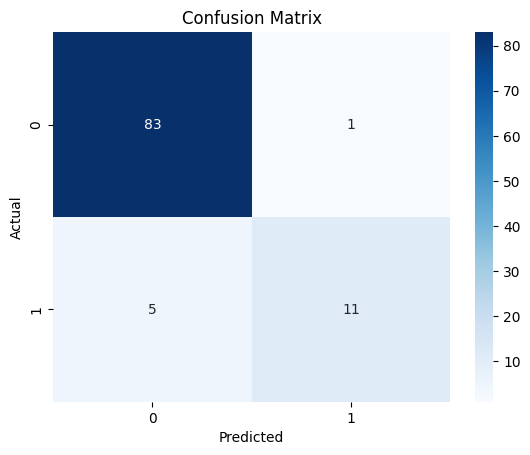

In [19]:
# Confusion Matrix - Heatmap

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

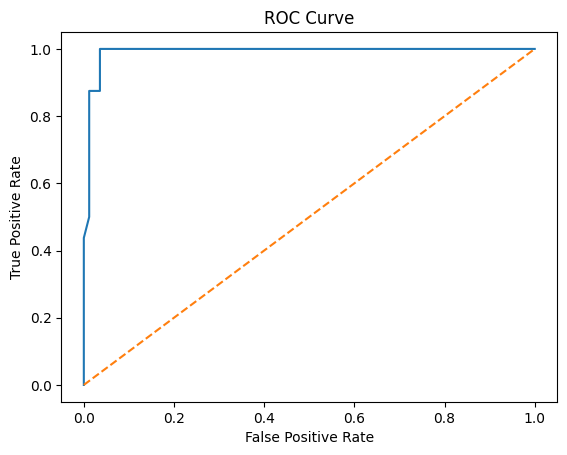

ROC-AUC Score: 0.9906994047619048


In [20]:
# ROC Curve

rf_probs = best_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, rf_probs))

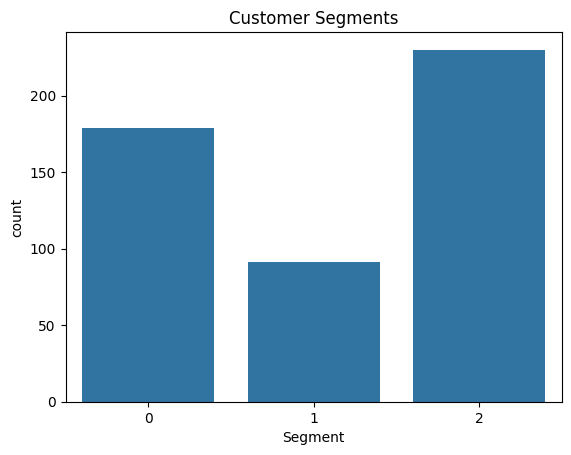

In [21]:
# Customer Segmentation - KMean

X_scaled = StandardScaler().fit_transform(X[numeric_cols])

kmeans = KMeans(n_clusters=3, random_state=42)
df["Segment"] = kmeans.fit_predict(X_scaled)

sns.countplot(x="Segment", data=df)
plt.title("Customer Segments")
plt.show()

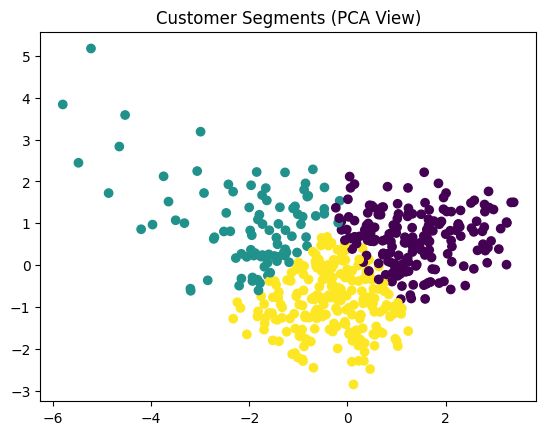

In [22]:
# PCA Visualization

pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

plt.scatter(pca_components[:,0], pca_components[:,1], c=df["Segment"])
plt.title("Customer Segments (PCA View)")
plt.show()

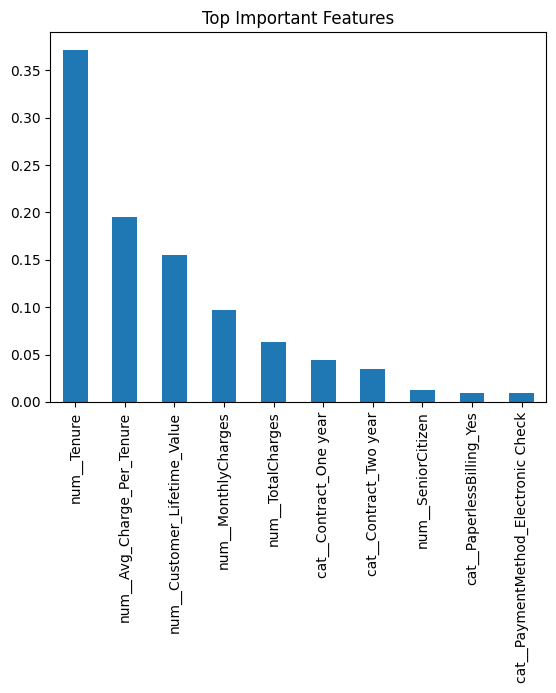

In [23]:
# FEature importance - Random Forest

importances = best_model.named_steps['classifier'].feature_importances_

feature_names = best_model.named_steps['preprocessing'].get_feature_names_out()

importance_df = pd.Series(importances, index=feature_names)
importance_df.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top Important Features")
plt.show()

In [24]:
# Model Comparison Table

results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Decision Tree,0.95
1,Random Forest,0.94


## Key Findings

- High monthly charges significantly increase churn risk
- Customers with short tenure are more likely to churn
- Random Forest performed better than Decision Tree
- Three customer segments were identified
- Segment 1 shows highest churn probability

## Business Recommendations

- Offer contract discounts for new customers
- Monitor high monthly charge customers
- Use predictive model for proactive retention campaigns
- Design segment-specific marketing strategies